In [65]:
import numpy as np
import pandas as pd
from tqdm import tqdm

class HybridWindowExtractor:
    def __init__(
        self,
        hand="Right",
        window_sec=1.5,
        step_sec=0.5,
        orig_fps=30.0,
        log_transform=False
    ):
        self.hand = hand
        self.orig_fps = float(orig_fps)
        self.dt = 1.0 / self.orig_fps
        self.window_size = int(window_sec * self.orig_fps)
        self.step_size = int(step_sec * self.orig_fps)
        self.log_transform = log_transform

    def extract_features(self, df_dict):
        """
        Main pipeline: Iterates over videos -> Groups by Valid Segment -> Slides Window -> Computes Physics.
        """
        all_window_rows = []

        for video_id, df in tqdm(df_dict.items(), desc=f"Extracting {self.hand} Hybrid Features"):
            
            # 1. Filter Hand
            if 'hand_label' in df.columns:
                dfh = df[df["hand_label"] == self.hand].copy()
            else:
                dfh = df.copy()

            # 2. Iterate over CONTINUOUS segments (Implicit Validity Handling)
            # This is safer than masks because we never interpolate over huge gaps
            if 'segment_id' not in dfh.columns:
                # Fallback if segment_id missing: treat whole video as one segment (risky if gaps exist)
                dfh['segment_id'] = 0 
            
            for seg_id, df_seg in dfh.groupby('segment_id'):
                if len(df_seg) < self.window_size:
                    continue

                # 3. Pre-calculate Physical Signals for this segment
                # (Vectors, Velocities, Angles, Areas)
                signals = self._compute_segment_signals(df_seg)

                # 4. Slide Window over this segment
                T = len(signals['vx'])
                for start in range(1, T - self.window_size + 1, self.step_size):
                    end = start + self.window_size
                    
                    # Slice all signals
                    win = {k: v[start:end] for k, v in signals.items()}
                    
                    # 5. Compute Scalar Features (The "Choice" of best metrics)
                    feats = self._compute_window_metrics(win)
                    
                    # Meta-data
                    feats['video_id'] = video_id
                    feats['window_start_frame'] = df_seg.iloc[start]['frame']
                    
                    all_window_rows.append(feats)

        return pd.DataFrame(all_window_rows)

    def _compute_segment_signals(self, df_seg):
        """
        Computes the raw time-series for Translation, Rotation, and Pose.
        """
        # --- A. Extract Keypoints ---
        def get_pts(lm_prefix):
            cols = [f"{lm_prefix}_{ax}_smooth" for ax in ["x", "y"]]
            return df_seg[cols].values

        pts0 = get_pts("lm_0")   # Wrist
        pts5 = get_pts("lm_5")   # Index Base
        pts17 = get_pts("lm_17") # Pinky Base

        # --- B. Translational (Wrist) ---
        # Velocity
        v_vec = np.diff(pts0, axis=0, prepend=pts0[:1]) / self.dt
        vx, vy = v_vec[:, 0], v_vec[:, 1]
        
        # Acceleration
        a_vec = np.diff(v_vec, axis=0, prepend=v_vec[:1]) / self.dt
        ax, ay = a_vec[:, 0], a_vec[:, 1]
        
        # Displacement (Frame-to-frame distance)
        d = np.concatenate(([0], np.sqrt(np.sum(np.diff(pts0, axis=0)**2, axis=1))))

        # --- C. Rotational (Orientation) ---
        # Vector from Wrist to Index (Hand Direction)
        v_orient = pts5 - pts0
        angles = np.arctan2(v_orient[:, 1], v_orient[:, 0])
        # Unwrap to handle -pi/pi jumps smoothly
        angles_unwrapped = np.unwrap(angles)
        # Angular Velocity (rad/s)
        ang_vel = np.diff(angles_unwrapped, prepend=angles_unwrapped[0]) / self.dt

        # --- D. Pose (Palm Shape) ---
        # Triangle Area between Wrist, Index, Pinky
        v1 = pts5 - pts0
        v2 = pts17 - pts0
        # Cross product 2D for area
        palm_area = 0.5 * np.abs(v1[:, 0] * v2[:, 1] - v1[:, 1] * v2[:, 0])

        return {
            'd': d, 'vx': vx, 'vy': vy, 'ax': ax, 'ay': ay,
            'ang_vel': ang_vel, 'palm_area': palm_area
        }

    def _compute_window_metrics(self, win):
        """
        Aggregates the 3s window into scalar features.
        """
        feats = {}
        
        # --- 1. Translational Quality (Smoothness/Efficiency) ---
        
        # Log Dimensionless Jerk (The Gold Standard for Smoothness)
        # Formula: (integral(jerk^2) * duration^5) / (path_length^2)
        jerk_x = np.diff(win['ax'], prepend=win['ax'][0]) / self.dt
        jerk_y = np.diff(win['ay'], prepend=win['ay'][0]) / self.dt
        int_sq_jerk = np.sum(jerk_x**2 + jerk_y**2) * self.dt
        
        tot_path = np.sum(win['d'])
        duration = len(win['d']) * self.dt
        
        if tot_path > 1e-6:
            dim_jerk = (duration**5 * int_sq_jerk) / (tot_path**2)
            feats['log_jerk'] = np.log1p(dim_jerk) if self.log_transform else dim_jerk
        else:
            feats['log_jerk'] = 0.0

        # Curvature (Precision)
        # k = |vx*ay - vy*ax| / |v|^3
        v_mag_sq = win['vx']**2 + win['vy']**2
        cross = np.abs(win['vx'] * win['ay'] - win['vy'] * win['ax'])
        curvature = cross / (v_mag_sq**1.5 + 1e-6)
        mean_k = np.mean(curvature)
        feats['log_curvature'] = np.log1p(mean_k) if self.log_transform else mean_k

        # Reversals (Fluidity)
        feats['num_reversals'] = self._count_reversals(win['vx'], win['vy'])

        # --- 2. Rotational Dynamics (Wrist Work) ---
        
        # Mean Angular Velocity (How much are they rotating the tool?)
        feats['ang_vel_mean'] = np.mean(np.abs(win['ang_vel']))
        
        # Rotational Stability (Standard Deviation of Ang Vel)
        # High std means "jittery" rotation
        feats['ang_vel_std'] = np.std(win['ang_vel'])

        # --- 3. Pose Stability (Hand Shape) ---
        
        # CV of Palm Area (The "Fumble" Detector)
        # If this is high, the hand is opening/closing rapidly (instability)
        area_mean = np.mean(win['palm_area'])
        if area_mean > 1e-6:
            feats['palm_area_cv'] = np.std(win['palm_area']) / area_mean
        else:
            feats['palm_area_cv'] = 0.0

        # --- 4. Intensity Stats ---
        v_mag = np.sqrt(v_mag_sq)
        feats['vel_mean'] = np.mean(v_mag)
        feats['vel_p90'] = np.percentile(v_mag, 90) # Peak burst speed

        return feats

    def _count_reversals(self, vx, vy):
        """
        Vectorized Reversal Counter using Cosine Similarity windowing.
        """
        w = int(0.3 * self.orig_fps) # 300ms window for direction check
        if len(vx) <= w: return 0.0
        
        # Compare vector at T vs vector at T+w
        v_now_x, v_now_y = vx[:-w], vy[:-w]
        v_fut_x, v_fut_y = vx[w:], vy[w:]
        
        dot = v_now_x * v_fut_x + v_now_y * v_fut_y
        mag_now = np.sqrt(v_now_x**2 + v_now_y**2)
        mag_fut = np.sqrt(v_fut_x**2 + v_fut_y**2)
        
        # Filter: Must be moving to reverse (avoid noise)
        is_moving = (mag_now > 15.0) & (mag_fut > 15.0)
        
        cosine = np.ones_like(dot)
        valid = is_moving & ((mag_now * mag_fut) > 1e-6)
        cosine[valid] = dot[valid] / (mag_now[valid] * mag_fut[valid])
        
        # Threshold: < -0.7 means > 135 degree turn
        is_reversing = (cosine < -0.7).astype(int)
        
        # Count 0->1 transitions (events)
        return float(np.sum(np.diff(is_reversing, prepend=0) == 1))

In [66]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
if os.getcwd().endswith("notebooks"):
    os.chdir("../")

In [67]:
processed_path = "data/processed/landmark_dataframes/"
paths = [os.path.join(processed_path, f) for f in os.listdir(processed_path) if f.endswith("30fps_processed.pkl")]

df_dict = {}
cols_to_keep = ['frame', 'hand_label', 'cx_smooth', 'cy_smooth']

# load df with where first column in csv serves as index
df_vid_name_map = pd.read_csv("data/scores/vid_name_map.csv", index_col=0)

with tqdm(total=len(paths), desc="Loading processed data") as pbar:
    for path in paths:
        vid = os.path.basename(path).replace("_30fps_processed.pkl", "")
        vid = vid.replace("hand_tracking_", "")
        participant_id = df_vid_name_map.loc[vid]['Participant Number']
        if int(participant_id) == 8:
            continue
        df_dict[(vid, int(participant_id))] = pd.read_pickle(path)#[cols_to_keep]
        pbar.update(1)

df_dict = dict(sorted(df_dict.items()))

df_scores = pd.read_csv("data/scores/merged_scores.csv")[['Vid_Name', 'QRS_Overal']]
grs_scores = df_scores.set_index('Vid_Name')['QRS_Overal'].to_dict()

Loading processed data:   6%|▌         | 5/86 [00:00<00:04, 16.21it/s]

Loading processed data:  97%|█████████▋| 83/86 [00:03<00:00, 25.13it/s]


In [68]:
# 1. Initialize and Prepare Data
extractor = HybridWindowExtractor(hand="Right", window_sec=1.5, step_sec=0.5)
df_window_features = extractor.extract_features(df_dict)

Extracting Right Hybrid Features:   0%|          | 0/83 [00:00<?, ?it/s]

Extracting Right Hybrid Features: 100%|██████████| 83/83 [00:40<00:00,  2.06it/s]


In [69]:
# quick check of the rango of windows per video

df_window_features['video_id'].value_counts().describe()

count      83.000000
mean      804.879518
std       345.712851
min       273.000000
25%       558.000000
50%       704.000000
75%       945.500000
max      1860.000000
Name: count, dtype: float64

In [70]:
feature_cols = [col for col in df_window_features.columns if col not in ['video_id', 'window_start_frame']]

# !!!might want to apply a log transform prior to video level aggregation to some more features!!!

df_window_features[feature_cols].describe()

,log_jerk,log_curvature,num_reversals,ang_vel_mean,ang_vel_std,palm_area_cv,vel_mean,vel_p90
count,6.680500e+04,66805.000000,66805.000000,66805.000000,66805.000000,66805.000000,66805.000000,66805.000000
mean,1.038975e+06,3.787738,2.345199,0.666374,0.936019,0.264347,105.832060,211.767129
std,1.780863e+06,158.351327,1.831621,0.848246,1.488702,0.248197,97.593619,215.903027
min,7.347033e+03,0.001791,0.000000,0.012433,0.015308,0.002284,2.584445,4.165599
25%,3.796996e+05,0.212717,1.000000,0.141644,0.168370,0.052784,34.419812,65.360279
50%,6.413851e+05,0.536298,2.000000,0.365893,0.448227,0.173780,75.764945,146.381519
75%,1.110723e+06,1.511239,4.000000,0.837948,1.047698,0.444270,146.680731,278.989377
max,6.656510e+07,22391.547895,10.000000,12.414626,18.612265,1.751071,874.407875,2293.410623


In [71]:
import numpy as np
import pandas as pd
from scipy.stats import iqr

def calculate_window_distributions(df_windows, feature_cols, group_col='video_id'):
    """
    Aggregates window-level local features into video-level distribution features.
    
    Args:
        df_windows (pd.DataFrame): DataFrame containing 1.5s window features.
        feature_cols (list): List of columns to aggregate (v, a, curvature, etc.).
        window_id_col (str): Column identifying the video/surgeon.
        
    Returns:
        pd.DataFrame: One row per video with aggregated distribution features.
    """
    
    # Define the aggregations we want
    # We use a dictionary to rename them nicely later
    aggs = {}
    for col in feature_cols:
        aggs[col] = [
            'median', 
            'std', 
            lambda x: np.percentile(x, 10), 
            lambda x: np.percentile(x, 90)
        ]

    # Perform the GroupBy Aggregation
    print(f"Aggregating {len(feature_cols)} features across {df_windows[group_col].nunique()} videos...")
    df_agg = df_windows.groupby(group_col)[feature_cols].agg(aggs)
    
    # Flatten the MultiIndex columns (e.g., ('velocity', 'mean') -> 'velocity_mean')
    new_cols = []
    for col_name, stat_name in df_agg.columns:
        if '<lambda_0>' in str(stat_name):
            stat_label = 'p10'
        elif '<lambda_1>' in str(stat_name):
            stat_label = 'p90'
        else:
            stat_label = stat_name
            
        new_cols.append(f"{col_name}_{stat_label}")
    
    df_agg.columns = new_cols
    df_agg.reset_index(inplace=True)
    
    return df_agg

# Example Usage Hypothesis Check:
# 1. Run this function on your 3s window dataframe.
# 2. Merge the result with your target scores (QRS).
# 3. Run your 'leakage_free_residual_analysis' on these new columns (e.g., 'curvature_p90').

In [72]:
df_agg = calculate_window_distributions(df_window_features, feature_cols, group_col='video_id')

Aggregating 8 features across 83 videos...


In [73]:
df_agg.head()

,video_id,log_jerk_median,log_jerk_std,log_jerk_p10,log_jerk_p90,log_curvature_median,log_curvature_std,log_curvature_p10,log_curvature_p90,num_reversals_median,...,palm_area_cv_p10,palm_area_cv_p90,vel_mean_median,vel_mean_std,vel_mean_p10,vel_mean_p90,vel_p90_median,vel_p90_std,vel_p90_p10,vel_p90_p90
0,"(2024-01-15_13-18-23, 1)",509415.587287,7.415833e+05,194925.958751,1.251870e+06,0.404920,12.579319,0.082898,1.944201,2.0,...,0.019859,0.647311,98.167789,99.731452,25.952362,231.953241,193.694911,242.873605,49.056872,492.698284
1,"(2024-01-15_13-37-36, 1)",848669.658657,1.038082e+06,254573.940605,2.465061e+06,0.737261,4.775749,0.120463,4.022913,2.0,...,0.020459,0.595309,63.909245,99.042398,18.664145,241.120819,136.942993,241.579712,33.572469,444.146087
2,"(2024-01-15_14-03-23, 1)",557894.618874,5.628224e+05,214574.815857,1.279911e+06,0.332853,2.873591,0.098564,2.491259,3.0,...,0.015490,0.746681,128.487443,93.079176,16.398334,226.567802,218.280895,212.126004,33.822493,486.331243
3,"(2024-01-15_14-32-45, 2)",496421.529810,2.867387e+06,213264.076675,1.695308e+06,0.473862,12.455131,0.107749,2.786746,2.0,...,0.021739,0.536331,74.219253,73.655411,22.915255,180.249554,142.805934,169.698670,42.986203,352.189448
4,"(2024-01-15_15-05-31, 2)",614555.359674,8.364208e+05,217081.506665,1.686871e+06,0.683485,7.224214,0.103673,4.659925,2.0,...,0.016400,0.542945,52.963995,74.797046,16.394953,184.219596,100.518297,161.316475,30.451731,377.838921


# Compute correlations between features and scores

In [106]:
from scipy.stats import pearsonr, spearmanr

candidate_features = [col for col in df_agg.columns if col not in ['video_id']]
scores = list(grs_scores.values())

#shuffle scores
import random
#random.seed(42)
#random.shuffle(scores)

feature_df = df_agg[candidate_features]
# compute correlation with scores both pearson and spearman
from scipy.stats import pearsonr, spearmanr
features = list(feature_df.columns)
pearson_corrs = []
spearman_corrs = []
for i in range(feature_df.shape[1]):
    pearson_corr, _ = pearsonr(feature_df.iloc[:, i], scores)
    spearman_corr, _ = spearmanr(feature_df.iloc[:, i], scores)
    pearson_corrs.append(pearson_corr)
    spearman_corrs.append(spearman_corr)

print("Top 10 features by Pearson correlation:")
top_pearson_indices = np.argsort(np.abs(pearson_corrs))[::-1][:12]
for idx in top_pearson_indices:
    print(f"{features[idx]}:        Pearson r = {pearson_corrs[idx]:.4f}, Spearman rho = {spearman_corrs[idx]:.4f}")

Top 10 features by Pearson correlation:
log_jerk_p90:        Pearson r = 0.4261, Spearman rho = 0.3648
num_reversals_std:        Pearson r = 0.4166, Spearman rho = 0.4233
log_jerk_std:        Pearson r = 0.3411, Spearman rho = 0.3532
palm_area_cv_median:        Pearson r = 0.3304, Spearman rho = 0.3367
palm_area_cv_p90:        Pearson r = 0.3099, Spearman rho = 0.3772
log_jerk_median:        Pearson r = 0.3081, Spearman rho = 0.2772
log_curvature_p90:        Pearson r = 0.2917, Spearman rho = 0.2308
palm_area_cv_std:        Pearson r = 0.2801, Spearman rho = 0.3328
log_jerk_p10:        Pearson r = 0.2689, Spearman rho = 0.2356
num_reversals_p90:        Pearson r = 0.2541, Spearman rho = 0.2349
vel_mean_p10:        Pearson r = -0.2510, Spearman rho = -0.2872
vel_p90_p10:        Pearson r = -0.2251, Spearman rho = -0.2591


# Compute correlations with residuals

In [76]:
# load top feature df and combine with aggregated window features
df_top_features = pd.read_csv("data/metrics/top_global_features.csv")
combined_df = pd.merge(df_top_features, df_agg, left_index=True, right_index=True)

In [77]:
combined_df

,Participant Number,Case_Number,GRS_Total,QRS_Overal,velocity_corr,total_path_Right,total_duration_Right,num_reversals_Right,nmu_peaks_Right,video_id,...,palm_area_cv_p10,palm_area_cv_p90,vel_mean_median,vel_mean_std,vel_mean_p10,vel_mean_p90,vel_p90_median,vel_p90_std,vel_p90_p10,vel_p90_p90
0,1,1,59.25,48.50,0.356401,53216.510143,535.000000,708,1089,"(2024-01-15_13-18-23, 1)",...,0.019859,0.647311,98.167789,99.731452,25.952362,231.953241,193.694911,242.873605,49.056872,492.698284
1,1,2,54.40,45.00,0.508696,29740.545434,288.000000,462,646,"(2024-01-15_13-37-36, 1)",...,0.020459,0.595309,63.909245,99.042398,18.664145,241.120819,136.942993,241.579712,33.572469,444.146087
2,1,3,74.50,60.50,0.429601,53325.837966,423.066667,740,1063,"(2024-01-15_14-03-23, 1)",...,0.015490,0.746681,128.487443,93.079176,16.398334,226.567802,218.280895,212.126004,33.822493,486.331243
3,2,1,49.25,39.25,0.407213,93483.269407,1281.700000,1278,2658,"(2024-01-15_14-32-45, 2)",...,0.021739,0.536331,74.219253,73.655411,22.915255,180.249554,142.805934,169.698670,42.986203,352.189448
4,2,2,49.00,38.00,0.537336,70969.138782,1010.966667,1059,2048,"(2024-01-15_15-05-31, 2)",...,0.016400,0.542945,52.963995,74.797046,16.394953,184.219596,100.518297,161.316475,30.451731,377.838921
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,28,2,72.25,59.75,0.580867,27798.774066,330.866667,346,670,"(2024-01-24_16-04-43, 28)",...,0.025942,0.683261,59.866529,78.146307,17.558596,175.538879,108.436708,189.008117,33.087559,370.805919
79,28,3,70.00,56.50,0.520950,40816.558241,355.966667,592,705,"(2024-01-24_16-21-06, 28)",...,0.015581,0.653993,89.392469,90.194278,13.280777,208.217746,160.081464,210.467735,23.531369,373.030826
80,29,1,49.75,40.75,0.445617,69635.433078,693.800000,1111,1546,"(2024-01-24_16-52-58, 29)",...,0.030811,0.657143,86.669486,82.298955,27.523623,209.502787,168.700094,174.928701,53.110428,430.642396
81,29,2,62.00,50.25,0.541216,54015.286863,590.333333,753,1277,"(2024-01-24_17-19-03, 29)",...,0.025700,0.588244,64.981449,95.027584,17.743191,245.580674,123.881504,193.059715,32.383027,464.220987


In [92]:
combined_df[['log_jerk_std', 'palm_area_cv_median']].describe()

,log_jerk_std,palm_area_cv_median
count,8.300000e+01,83.000000
mean,1.615625e+06,0.207235
std,8.384782e+05,0.090934
min,5.628224e+05,0.078214
25%,1.000242e+06,0.141636
50%,1.365408e+06,0.180029
75%,2.010156e+06,0.253010
max,5.554104e+06,0.455017


In [116]:
# leakage free version:

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import pearsonr
from tqdm import tqdm
from sklearn.linear_model import Ridge, RidgeCV

def leakage_free_residual_analysis(
    df,
    candidate_features,
    target='QRS_Overal',
    surgeon_col='Participant Number',
    pcs_to_use=[0],
    pca_features=['total_path_Right', 'total_duration_Right', 'num_reversals_Right', 'nmu_peaks_Right']
):
    """
    Evaluates candidate features by identifying their contribution to residuals
    using a Leave-One-Surgeon-Out cross-validation approach.
    """
    unique_surgeons = df[surgeon_col].unique()
    fold_results = []

    for surgeon_out in tqdm(unique_surgeons, desc="Analyzing Folds"):
        # Split Data
        df_train = df[df[surgeon_col] != surgeon_out].dropna(subset=[target] + candidate_features + pca_features).copy()
        
        # 1. Baseline PCA & Model (Fit on Train ONLY)
        scaler = StandardScaler()
        X_train_pca_raw = scaler.fit_transform(df_train[pca_features])
        
        pca = PCA(n_components=max(pcs_to_use) + 1)
        train_pcs = pca.fit_transform(X_train_pca_raw)
        
        # Define baseline columns
        pc_cols = [f'PC{i+1}' for i in range(train_pcs.shape[1])]
        df_train[pc_cols] = train_pcs
        used_pc_cols = [pc_cols[i] for i in pcs_to_use]
        
        # 2. Baseline Model (Train residuals)
        y_train = df_train[target].values
        pc_model = Ridge(alpha=0.5)
        pc_model.fit(df_train[used_pc_cols+['velocity_corr']], y_train)
        
        train_residuals = y_train - pc_model.predict(df_train[used_pc_cols+['velocity_corr']])
        #random.shuffle(train_residuals)
        pc_resid_var = np.var(train_residuals)

        # 3. Evaluate Candidate Features on this Fold
        for feat in candidate_features:
            # Partial R2 calculation on train set
            X_full = df_train[used_pc_cols+['velocity_corr']+[feat]]
            scaler_full = StandardScaler()
            X_full = scaler_full.fit_transform(X_full)
            full_model = Ridge(alpha=0.5)
            full_model.fit(X_full, y_train)
            
            full_resid_var = np.var(y_train - full_model.predict(X_full))
            partial_r2 = 1 - (full_resid_var / pc_resid_var)
            
            # Correlation with residuals
            r, _ = pearsonr(df_train[feat], train_residuals)
            
            fold_results.append({
                'Fold_Surgeon_Out': surgeon_out,
                'Feature': feat,
                'Partial_R2': partial_r2,
                'Resid_Corr': r
            })

    # ==============================
    # 4. Aggregate Results across all folds
    # ==============================
    results_df = pd.DataFrame(fold_results)
    
    # We want to know:
    # 1. Mean Partial R2
    # 2. Selection Frequency (how often is it in the top 10?)
    summary = results_df.groupby('Feature').agg({
        'Partial_R2': ['mean', 'std'],
        'Resid_Corr': ['mean', 'std']
    }).reset_index()
    
    summary.columns = ['Feature', 'Mean_Partial_R2', 'Std_Partial_R2', 'Mean_Resid_Corr', 'Std_Resid_Corr']

    results_df['Resid_Corr'] = results_df['Resid_Corr'].abs()

    results_df['rank_score'] = results_df['Resid_Corr'].abs()* results_df['Partial_R2'].abs()
    
    # Calculate "Stability": How often was this feature in the top 10 of its fold?
    results_df['Rank'] = results_df.groupby('Fold_Surgeon_Out')['Resid_Corr'].rank(ascending=False)
    stability = results_df[results_df['Rank'] <= 2]['Feature'].value_counts() / len(unique_surgeons)
    stability = stability.rename('Selection_Stability').reset_index().rename(columns={'index': 'Feature'})
    
    final_summary = summary.merge(stability, on='Feature', how='left').fillna(0)
    
    return final_summary.sort_values('Mean_Resid_Corr', ascending=False)    

# Usage:
#exploratory_cols.remove('velocity_corr_moving')
candidate_features = [col for col in combined_df.columns if col not in ['Participant Number', 'Case_Number', 'GRS_Total', 'QRS_Overal', 'velocity_corr', 'total_path_Right', 'total_duration_Right', 'num_reversals_Right', 'nmu_peaks_Right', 'video_id']]
df_res_leakage_free = leakage_free_residual_analysis(combined_df, candidate_features)
df_res_leakage_free

Analyzing Folds:   0%|          | 0/28 [00:00<?, ?it/s]

Analyzing Folds: 100%|██████████| 28/28 [00:07<00:00,  3.56it/s]


,Feature,Mean_Partial_R2,Std_Partial_R2,Mean_Resid_Corr,Std_Resid_Corr,Selection_Stability
15,log_jerk_std,0.109542,0.011576,0.267277,0.018178,0.964286
20,palm_area_cv_median,0.080543,0.009170,0.260225,0.017805,1.000000
22,palm_area_cv_p90,0.057510,0.008792,0.198965,0.018753,0.035714
10,log_curvature_p90,0.060438,0.009168,0.182400,0.023351,0.000000
14,log_jerk_p90,0.065091,0.010272,0.172833,0.022139,0.000000
13,log_jerk_p10,0.045401,0.008348,0.143927,0.027296,0.000000
19,num_reversals_std,0.033014,0.004115,0.135873,0.014905,0.000000
9,log_curvature_p10,0.056454,0.007839,0.133315,0.019615,0.000000
23,palm_area_cv_std,0.037300,0.006473,0.130613,0.020645,0.000000
24,vel_mean_median,0.028038,0.003259,0.105978,0.017007,0.000000


In [91]:
combined_df[['log_jerk_std', 'palm_area_cv_median', 'palm_area_cv_p90', 'log_jerk_p90']].corr()

,log_jerk_std,palm_area_cv_median,palm_area_cv_p90,log_jerk_p90
log_jerk_std,1.000000,-0.137659,-0.211917,0.667942
palm_area_cv_median,-0.137659,1.000000,0.682552,-0.004720
palm_area_cv_p90,-0.211917,0.682552,1.000000,-0.041555
log_jerk_p90,0.667942,-0.004720,-0.041555,1.000000


# Hybrid Model 

Starting Leave-One-Surgeon-Out CV with 28 folds...


LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 77.47it/s]



          HYBRID MODEL (RIDGE) LOSOCV RESULTS
Overall Correlation (R): 0.7806
Overall MAE: 4.8520
Overall Std Dev of Errors: 3.4083

--- Per-Fold Performance Summary ---
           Train_MAE  Test_MAE  Test_Corr
SurgeonID                                
1           4.350170  6.436791  -0.302804
2           4.473542  4.756029   0.990370
3           4.403286  7.562087   0.653000
4           4.360196  7.419088   0.196740
5           4.359421  7.462852   0.925884
6           4.564319  1.937720   0.990654
7           4.366587  6.591216  -0.767165
9           4.460621  4.794443  -0.923950
10          4.491055  4.220933   0.993873
11          4.548480  2.298202  -0.984470
12          4.462447  5.008074  -0.455633
13          4.568811  1.809224   0.977363
14          4.499519  5.057442   0.923876
15          4.424397  6.379412   0.991238
16          4.333956  7.230509   0.595858
17          4.580602  1.412254   0.998015
18          4.434639  5.616077   0.986062
19          4.437959  5.034330 

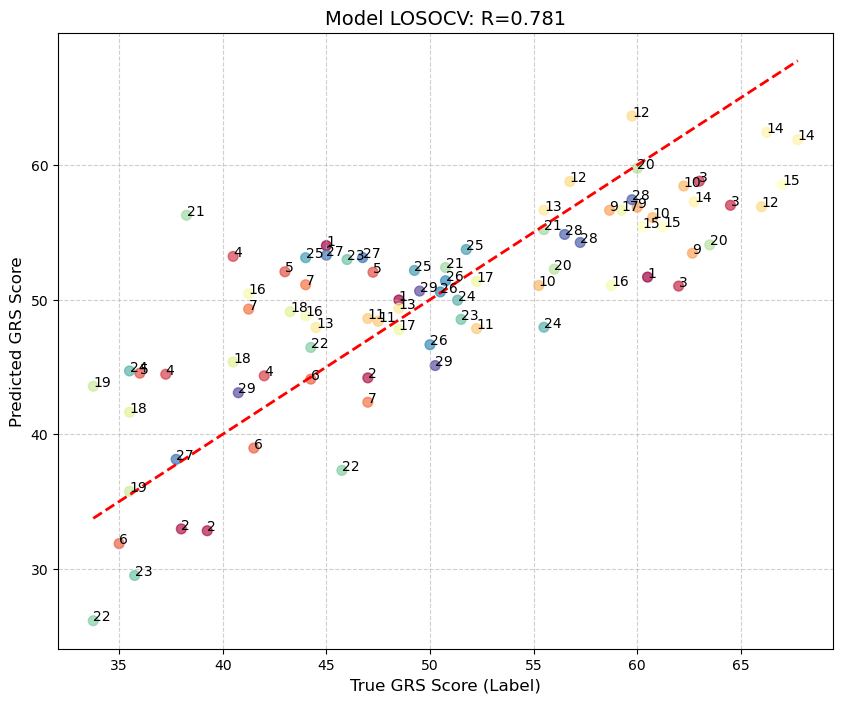

In [120]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- 1. Prepare Data (Code adapted from your input) ---

# --- IMPORTANT ASSUMPTIONS ---
# 1. merged_feature_df is available and correctly indexed.
# 2. 'QRS_Overal' is the column for the true scores (y).
# 3. 'Participant Number' is the column for SurgeonID.
# 4. Feature columns are PC1, PC2, PC3, BoW_2, BoW_20.
# ------------------------------

feature_cols = [col for col in ['total_path_Right', 'total_duration_Right', 'num_reversals_Right', 'nmu_peaks_Right']]
additional_feature_cols = ['velocity_corr', 'log_jerk_std', 'palm_area_cv_median']  # From handcrafted features analysis
all_feature_cols = feature_cols + additional_feature_cols
X = combined_df[all_feature_cols].values
y = combined_df['QRS_Overal'].values

# Extract the Surgeon IDs for the folds
surgeon_ids = combined_df['Participant Number'].values # Assuming 'Participant Number' holds the unique surgeon/participant identifier

unique_surgeons = np.unique(surgeon_ids)
predictions = []
true_scores = []
fold_results = {} # To store results per fold

# --- 2. LOSOCV Loop ---
print(f"Starting Leave-One-Surgeon-Out CV with {len(unique_surgeons)} folds...")

# We will collect fold-level predictions for plotting
all_fold_preds = []
all_fold_true = []
all_fold_surgeons = []


for surgeon_out in tqdm(unique_surgeons, desc="LOSOCV Folds"):
    
    # Define Folds
    test_indices = np.where(surgeon_ids == surgeon_out)[0]
    train_indices = np.where(surgeon_ids != surgeon_out)[0]
    
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]

    # scale features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)


    # PCA but only on feature_cols
    pca = PCA(n_components=min(3, len(feature_cols)))  # Adjust number of components as needed
    X_train_pca = pca.fit_transform(X_train[:, :len(feature_cols)])
    X_test_pca = pca.transform(X_test[:, :len(feature_cols)])
    
    # component list to keep
    component_list = [0]  # Keep only the first principal component
    X_train_pca = X_train_pca[:, component_list]
    X_test_pca = X_test_pca[:, component_list]
    
    # Combine PCA features with additional features
    X_train = np.hstack((X_train_pca, X_train[:, len(feature_cols):]))
    X_test = np.hstack((X_test_pca, X_test[:, len(feature_cols):]))

    # 3. Train Model
    # Using the optimized alpha=0.5
    model = Ridge(alpha=0.5) 
    model.fit(X_train, y_train)
    
    # Predict and store
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate Fold Metrics
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_corr, _ = pearsonr(y_test, y_test_pred)
    
    fold_results[surgeon_out] = {
        'Train_MAE': train_mae,
        'Test_MAE': test_mae,
        'Test_Corr': test_corr
    }
    
    # Store results for overall metrics and plotting
    predictions.extend(y_test_pred)
    true_scores.extend(y_test)
    all_fold_preds.extend(y_test_pred)
    all_fold_true.extend(y_test)
    all_fold_surgeons.extend([surgeon_out] * len(y_test_pred))

# --- 4. Evaluate and Print Results ---
final_predictions = np.array(predictions)
final_true_scores = np.array(true_scores)

hybrid_mae = mean_absolute_error(final_true_scores, final_predictions)
hybrid_std = np.std(np.abs(final_true_scores - final_predictions))
hybrid_corr, _ = spearmanr(final_true_scores, final_predictions)

# Create a DataFrame for per-fold results
fold_results_df = pd.DataFrame.from_dict(fold_results, orient='index')
fold_results_df.index.name = 'SurgeonID'

print("\n=================================================")
print("          HYBRID MODEL (RIDGE) LOSOCV RESULTS")
print("=================================================")
print(f"Overall Correlation (R): {hybrid_corr:.4f}")
print(f"Overall MAE: {hybrid_mae:.4f}")
print(f"Overall Std Dev of Errors: {hybrid_std:.4f}")
print(f"\n--- Per-Fold Performance Summary ---")
print(fold_results_df)

# --- 5. Visualization ---
plt.figure(figsize=(10, 8))

# Scatter plot
scatter = plt.scatter(
    all_fold_true, 
    all_fold_preds, 
    c=all_fold_surgeons, # Color by surgeon ID
    cmap='Spectral', 
    label='Predicted Scores',
    s=50,
    alpha=0.7
)

for i, sid in enumerate(surgeon_ids):
    plt.annotate(f'{sid}', (all_fold_true[i], all_fold_preds[i]))

# Diagonal Line (Perfect prediction)
plt.plot(
    [min(final_true_scores), max(final_true_scores)], 
    [min(final_true_scores), max(final_true_scores)], 
    'r--', 
    lw=2,
    label='Ideal Prediction (y=x)'
)

plt.xlabel("True GRS Score (Label)", fontsize=12)
plt.ylabel("Predicted GRS Score", fontsize=12)
plt.title(f"Model LOSOCV: R={hybrid_corr:.3f}", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()